In [ ]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from data_loader import *

# Load Different Datasets

In [ ]:
A = load_movielen_latest_small('ml-latest-small', binary=True)
#A = load_movielen_100k('ml-100k')
#A = load_movielen_1m('ml-1m')
#A = load_movielen_10m('ml-10m')
#A = load_movielen_25m('ml-25m')
#A = load_netflix('Netflix')

Loading done!len dataset 64.99%...

# Collect Stats and Do SVD

In [3]:
m,n = A.shape
A_shifted = A.copy()
η = np.sum(A) / (m)

assert(isinstance(A, np.ndarray) or isinstance(A, sp.csr_matrix))
sparse = not isinstance(A, np.ndarray)

maxk = min(m,n)
assert(m*n <= 1<<24 or sparse)
if m*n > 1<<24 or sparse:
    maxk = min(500, min(m,n)-1) # sp.svds requres 0 < k < min(m,n) (not <= min(m,n))

print(f'----- Metadata of A -----')
print('A is stored as '+('sparse matrix (sp.csr_matrix).' if sparse else 'dense matrix (np.ndarray).'))
print(f'm = {m}, n = {n}')
print(f'average #rec = {η:.2f}')
print(f'k is taken from 1 to {maxk}')

print('Doing SVD...')
if sparse:
    U,  S,  Vh  = sp.linalg.svds(A, k=maxk)
    # scipy.sparse.linalg.svds returns singular values in ascending order
    S = S[::-1]
    U = U[:,::-1]
    Vh= Vh[::-1,:]
else:
    U,  S,  Vh  = np.linalg.svd(A)
V = Vh.T.conj()

----- Metadata of A -----
A is stored as sparse matrix (sp.csr_matrix).
m = 610, n = 9742
average #rec = 134.04
k is taken from 1 to 500
Doing SVD...


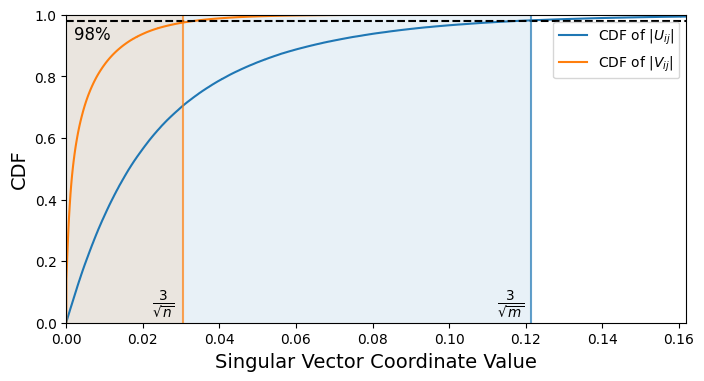

In [4]:
plt.figure(figsize=(8, 4))

# plot cdf
ax = plt.gca()
ax.ecdf(np.abs(U[:, :min(m,n)].flatten()), label='CDF of $|U_{ij}|$')
ax.ecdf(np.abs(V[:, :min(m,n)].flatten()), label='CDF of $|V_{ij}|$')

# add range annotations
plt.axhline(0.98, linestyle='--', color='black')
plt.text(0.002, 0.92, '98%', fontsize=12)

plt.axvline(3/np.sqrt(m), color='C0', alpha=0.7)
plt.axvline(3/np.sqrt(n), color='C1', alpha=0.7)

from matplotlib import patches
rect = patches.Rectangle(
    (0., 0.),
    3/np.sqrt(m),
    1,
    facecolor='C0',
    alpha=0.1
)
ax.add_patch(rect)
rect = patches.Rectangle(
    (0., 0.),
    3/np.sqrt(n),
    1,
    facecolor='C1',
    alpha=0.1
)
ax.add_patch(rect)

plt.text(3/np.sqrt(m)-0.009, 0.05, r'$\frac{3}{\sqrt{m}}$', fontsize=14)
plt.text(3/np.sqrt(n)-0.008, 0.05, r'$\frac{3}{\sqrt{n}}$', fontsize=14)

# lagend and label
plt.legend()

plt.xlabel('Singular Vector Coordinate Value', fontsize=14)
plt.ylabel('CDF', fontsize=14)
plt.xlim(left=0, right=4*max(1/np.sqrt(m), 1/np.sqrt(n)))
plt.ylim(0, 1)

# save fig
plt.savefig('figures/uv_stat_ecdf.pdf', dpi=400, bbox_inches='tight')